In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [3]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [4]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [6]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [7]:
df = df.dropna()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   object 
 3   Dependents         7032 non-null   object 
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   object 
 6   Multiple Lines     7032 non-null   object 
 7   Internet Service   7032 non-null   object 
 8   Online Security    7032 non-null   object 
 9   Online Backup      7032 non-null   object 
 10  Device Protection  7032 non-null   object 
 11  Tech Support       7032 non-null   object 
 12  Streaming TV       7032 non-null   object 
 13  Streaming Movies   7032 non-null   object 
 14  Contract           7032 non-null   object 
 15  Paperless Billing  7032 non-null   object 
 16  Payment Method     7032 non-n

In [9]:
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [10]:
X = pd.get_dummies(X, drop_first=True)

In [11]:
feature_names = X.columns

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic regression

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

model-comparison block

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "MLP Neural Network": MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    solver="adam",
    max_iter=1000,
    early_stopping=True,
    random_state=42
)
}

results = []

for name, model in models.items():
    if name in ["Logistic Regression", "MLP Neural Network"]:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print(results_df.round(3))

                 Model  Accuracy  Precision  Recall     F1    AUC
0  Logistic Regression     0.812      0.700   0.580  0.634  0.863
1        Random Forest     0.793      0.676   0.506  0.579  0.839
2              XGBoost     0.783      0.630   0.547  0.585  0.841
3   MLP Neural Network     0.803      0.679   0.567  0.618  0.860


In [21]:
import shap
xgb_model = models["XGBoost"]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.close()

feature_importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(5))

              Feature  Importance
0       Tenure Months    0.799470
25  Contract_Two year    0.740157
6      Dependents_Yes    0.585329
1     Monthly Charges    0.488219
2       Total Charges    0.379282


AUC: 0.8625831790663933


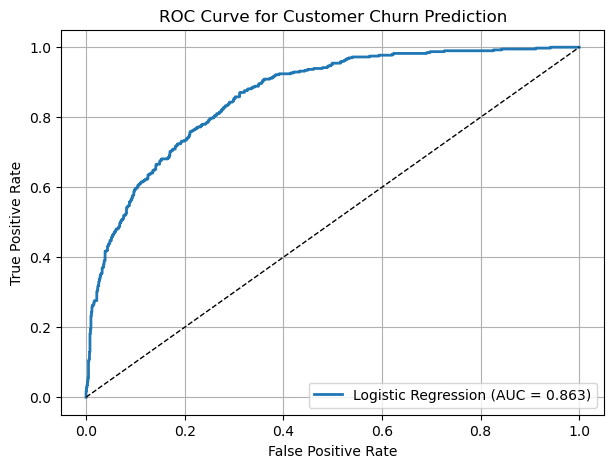

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Use Logistic Regression (best-performing model)
best_model = models["Logistic Regression"]

y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC:", auc_score)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0,1],[0,1],'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Customer Churn Prediction")

plt.legend(loc="lower right")
plt.grid(True)

plt.savefig("roc_curve_churn.png", dpi=300, bbox_inches="tight")

plt.show()

In [23]:
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Customer Churn Decision Support", layout="wide")

st.title("Customer Churn Prediction and Decision Support Dashboard")

st.write(
    "This dashboard predicts customer churn risk and supports customer retention decision-making."
)

st.sidebar.header("Customer Information")

tenure = st.sidebar.slider("Tenure Months", 0, 72, 12)
monthly_charges = st.sidebar.number_input("Monthly Charges", 0.0, 200.0, 70.0)
total_charges = st.sidebar.number_input("Total Charges", 0.0, 10000.0, 1000.0)

contract = st.sidebar.selectbox(
    "Contract Type",
    ["Month-to-month", "One year", "Two year"]
)

dependents = st.sidebar.selectbox("Dependents", ["No", "Yes"])
internet_service = st.sidebar.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])

customer_data = pd.DataFrame({
    "Tenure Months": [tenure],
    "Monthly Charges": [monthly_charges],
    "Total Charges": [total_charges],
    "Contract": [contract],
    "Dependents": [dependents],
    "Internet Service": [internet_service]
})

st.subheader("Input Customer Profile")
st.dataframe(customer_data)

if st.button("Predict Churn Risk"):
    # Replace this section with saved preprocessing/model pipeline
    churn_probability = 0.65  # placeholder example

    st.subheader("Prediction Result")
    st.metric("Predicted Churn Probability", f"{churn_probability:.2%}")

    if churn_probability >= 0.5:
        st.error("High churn risk")
        st.write("Recommended action: prioritise this customer for retention intervention.")
    else:
        st.success("Low churn risk")
        st.write("Recommended action: continue regular engagement.")

2026-05-27 21:35:22.022 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 21:35:22.024 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 21:35:22.389 
  command:

    streamlit run C:\Users\User\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-27 21:35:22.390 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 21:35:22.392 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 21:35:22.394 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 21:35:22.395 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runni